# In-Class Assignment 4

**Credit: These exercises follow from work by Mike Zingale's computational lectures.**

## Learning Objectives

* building stellar models using approximations
* 

We will be picking up from ICA2. These exercises require the solutions from ICA2 and are included here. 

In [1]:
from sympy import init_session
init_session(use_latex="mathjax")
%matplotlib inline

IPython console for SymPy 1.13.3 (Python 3.11.8-64-bit) (ground types: python)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.13.3/



## stellar model

In [2]:
rho = symbols('rho', cls=Function)
rhoc = symbols('rho_c')
qc = symbols('q_c')
Pc = symbols('P_c')
G = symbols('G')
Mstar, Rstar = symbols('M_\star R_\star')
r = symbols('r')
xi = symbols('xi')
mu = symbols('mu')
k = symbols('k')
m_u = symbols('m_u')

Imagine a star has a density profile of the form:

$$\rho(r) = \rho_c \left [ 1 - \left (\frac{r}{R_\star} \right )^3 \right ]$$

where $\rho_c$ is the central density.


In [3]:
rho = rhoc * (1 - (r/Rstar)**3)
rho

    ⎛        3   ⎞
    ⎜       r    ⎟
ρ_c⋅⎜1 - ────────⎟
    ⎜           3⎟
    ⎝    R_\star ⎠

We found expression for the central density in terms of
     $R_\star$ and $M_\star$.


In [4]:
M = integrate(4*pi*r**2*rho, (r, 0, Rstar))
M

           3    
2⋅π⋅R_\star ⋅ρ_c
────────────────
       3        

In [5]:
rhoc_value = solve(Eq(M, Mstar), rhoc)[0]
rhoc_value

 3⋅M_\star  
────────────
           3
2⋅π⋅R_\star 

In [6]:
# replace our original rho(r) equation with our computed value of rhoc
rho = rho.subs(rhoc, rhoc_value)
rho

          ⎛        3   ⎞
          ⎜       r    ⎟
3⋅M_\star⋅⎜1 - ────────⎟
          ⎜           3⎟
          ⎝    R_\star ⎠
────────────────────────
                 3      
      2⋅π⋅R_\star       

### 1. - Computing Central Pressure 


Our goal is to find an equation for the pressure as a function of radius $P(r)$ using the above $\rho(r)$ we computed. 

Recall our equation for hydrostatic equilibrium (HSE):

$$
\frac{dP}{dr} = - \rho (r) g (r)
$$

where 

$$
g(r) = - \frac{G M(r)}{r^2}
$$

Also assume that the pressure vanishes at the surface $P(R_\star)\rightarrow0$.


Your answer will be in the form of $P(r) = P_c \times$
    (polynomial in $r/R_\star$).  
    
1. Integrate our mass equation now from 0 to some radius $r$ (as opposed to 0 to $R_\star$ when looking for $\rho_{c}$). This should give us $M(r)$.
    
2. Compute $P(r)$ in terms of $M_\star$ and $R_\star$ by integrating our HSE equation from 0 to $R_\star$.
    
3. Solve for $P_c$ by setting $P(R_\star)=0$.

4. Compute a numerical value for $P_c$ by substituting in values for $M_\star$ and $R_\star$ and compare to the Sun's central pressure of about $2\times10^{17} \ (\rm{dyne} \ \rm{cm}^{-2})$.

5. Plot the resulting pressure profile $P(r)$ by defining a new function $z=P(r)/P_c$, then substitute ($r$ for a fractional radius of the total radius $R_\star$ as $\xi \times R_\star$). Run the cells to plot the result.



In [7]:
# compute M(r) from 0 to r here
M = integrate(4*pi*r**2*rho, (r, 0, r))
M

           3            6
2⋅M_\star⋅r    M_\star⋅r 
──────────── - ──────────
         3             6 
  R_\star       R_\star  

In [8]:
# compute P(r) in terms from of Mstar and Rstar by integrating from 0 to Rstar
P = Pc + integrate(-G*M/r**2*rho, (r, 0, Rstar))
P

              2      
  63⋅G⋅M_\star       
- ───────────── + P_c
              4      
  80⋅π⋅R_\star       

In [9]:
# solve for Pc by setting P=0
Pc = solve(Eq(P, 0), Pc)[0]
Pc

            2
63⋅G⋅M_\star 
─────────────
            4
80⋅π⋅R_\star 

In [10]:
msun = 2e33    # g
rsun = 6.96e10 # cm
G_cgs = 6.67e-8

# compute a numercal value for Pc here
Pc.subs(Rstar,rsun).subs(Mstar,msun).subs(G,G_cgs).evalf()

2.85003082072768e+15

In [11]:
# now, find a general expression for pressure by passing Pc computed above and integrating HSE from 0 to r
P = Pc + integrate(-G*M/r**2*rho, (r, 0, r))
P

            2              2  2              2  5              2  8
63⋅G⋅M_\star    3⋅G⋅M_\star ⋅r    9⋅G⋅M_\star ⋅r    3⋅G⋅M_\star ⋅r 
───────────── - ─────────────── + ─────────────── - ───────────────
            4               6                  9                12 
80⋅π⋅R_\star     2⋅π⋅R_\star       10⋅π⋅R_\star     16⋅π⋅R_\star   

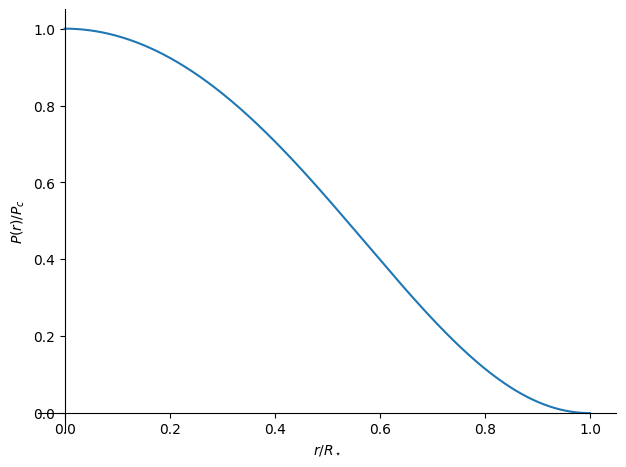

In [12]:
# run these cells below to view our pressure profile. 
z = simplify((P/Pc).subs(r, xi*Rstar))
plot(z, (xi, 0, 1), xlabel=r"$r/R_\star$", ylabel=r"$P(r)/P_{c}$")

### 2. - Computing Central Temperature

The central temperature, assuming the ideal gas law, is:

$$T_c = \frac{\mu m_u P_c}{\rho_c k}$$

For our density profile this should be

$$T_c = \frac{21}{40} \frac{G M_\star}{R_\star} \frac{\mu m_u}{k}$$

while for the constant density model, the coefficient was 1/2.

1. Compute $T_c$ symbolically and confirm the coefficient 21/40.

2. Compute a numerical value for the central temperature and compare to the central temperature of the Sun. 

3. 

Okay great, but we still need to know the composition before we can compute the temperature. 

We'll look at two choices here:

In [13]:
# compute Tc here and confirm the prefactor
Tc = mu*m_u*Pc/(k*rhoc_value)
Tc

21⋅G⋅M_\star⋅mᵤ⋅μ
─────────────────
  40⋅R_\star⋅k   

i. pure H composition has $\mu = 1/2$, compute $T_{c}$ for this composition.

In [14]:
mu_cgs = 0.5
m_u_cgs = 1.66e-24
k_cgs = 1.38e-16
Tc.subs(Mstar, msun).subs(Rstar,rsun).subs(k,k_cgs).subs(G,G_cgs).subs(m_u,m_u_cgs).subs(mu,mu_cgs).evalf()/1e7

0.605208333333333

ii. pure He composition has $\mu = 4/3$

In [15]:
# compute Tc here for this composition
mu_cgs = 4/3.
Tc = mu*m_u*Pc/(k*rhoc_value)

Tc.subs(Mstar, msun).subs(Rstar,rsun).subs(k,k_cgs).subs(G,G_cgs).subs(m_u,m_u_cgs).subs(mu,mu_cgs).evalf()/1e7

1.61388888888889

The central pressure for the constant-density model (HKT 1.39) was

$$P_c = \frac{3}{8\pi} \frac{GM_\star^2}{R_\star^4}$$

Here, with the cubic density profile, we find 

$$P_c = \frac{63}{80\pi} \frac{G M_\star^{2}}{R_\star^{4}}$$

The pressure is greater in this model because more mass is concentrated toward the center of the star, increasing the force of gravity throughout, making the outer layers weigh more.

The temperature is the _almost the same_ in both models, since both the central pressure and central density increase by the here.

Let's evaluate $P_c/\rho_c$ for our model

### 3. Comparing the Pressure Profiles to a MS stellar model

1. load the MESA data using pandas, 
2. retrieve the radius and pressure profiles
3. compute the max / central pressure
4. plot the MESA data $r/R_\star$ vs $P(r)/P_c$ and compare directly to our plot for these data using our approximate density profile
5. comment briefly on the difference of the two profiles and think what might be contributing to the difference

In [16]:
import pandas as pd
one_m_sun_ms = pd.read_csv('data/M1_default_profile8.data',sep=r'\s+',header=4)
one_m_sun_ms.columns

Index(['mass', 'radius', 'luminosity', 'pressure', 'logRho', 'logT', 'energy',
       'entropy', 'cp', 'gamma1', 'grada', 'mu', 'free_e', 'ye', 'pgas',
       'prad', 'gradr', 'gradT', 'velocity', 'conv_vel', 'opacity', 'eps_nuc',
       'pp', 'cno', 'tri_alfa', 'eps_nuc_neu_total', 'non_nuc_neu', 'eps_grav',
       'h1', 'he3', 'he4', 'c12', 'n14', 'o16', 'ne20', 'mg24', 'si28', 's32',
       'ar36', 'ca40', 'ti44', 'cr48', 'fe52', 'fe54', 'fe56', 'ni56', 'eta',
       'log_omega', 'v_rot', 'j_rot', 'dynamo_log_B_r', 'dynamo_log_B_phi',
       'log_D_conv', 'log_D_semi', 'log_D_ovr', 'log_D_thrm'],
      dtype='object')

In [17]:
one_m_sun_radius_ms = one_m_sun_ms['radius']
one_m_sun_pressure_ms = one_m_sun_ms['pressure']

In [18]:
one_m_sun_Pc = max(one_m_sun_pressure_ms)
one_m_sun_Rstar = max(one_m_sun_radius_ms)

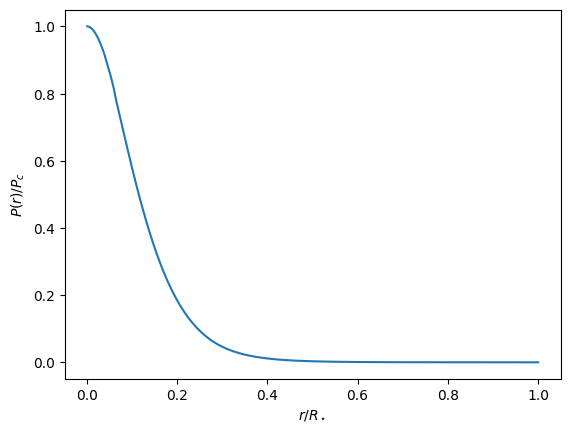

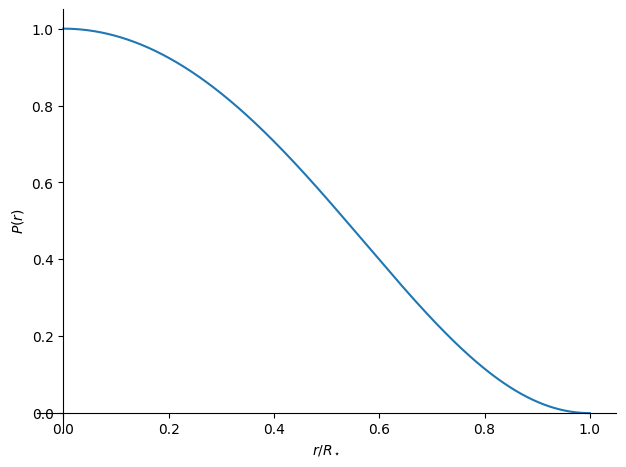

In [19]:
plt.plot(one_m_sun_radius_ms/one_m_sun_Rstar,one_m_sun_pressure_ms/one_m_sun_Pc)
plt.xlabel('$r/R_\star$');plt.ylabel(r'$P(r)/P_c$')
plot(z,(xi, 0, 1), xlabel=r"$r/R_\star$", ylabel=r"$P(r)$")

comment on the difference for the two pressure profiles here...